# Práctica 1: Aprendizaje Automático
**Predicción de Subscripción a un Producto Bancario**

* **Autores:** Jaime del Campo Montaña & David Alexander Torres Paillacho
* **NIA's:** 100495957 & 100522187

In [26]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import joblib

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

# Semilla fijada al NIA
RANDOM_STATE = 100522187

---
## 2. EDA Simplificado
Exploración inicial para guiar la estrategia de preprocesamiento. Comprobamos: dimensiones, tipos de variable, nulos/unknowns, cardinalidad, columnas constantes/ID, tipo de problema y balanceo de clases.

In [27]:
dataframe = pd.read_pickle('bank_15.pkl')
print(f"Dataset cargado: {dataframe.shape[0]} filas × {dataframe.shape[1]} columnas")
dataframe.head()

Dataset cargado: 11000 filas × 17 columnas


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### 2.1 Tamaño del dataset y tipos de variables

In [28]:
filas, columnas = dataframe.shape
print(f"El dataset tiene {filas} filas y {columnas} columnas.\n")

#resumen por columna
resumen = pd.DataFrame({
    'Tipo': dataframe.dtypes,
    'Nulos (NaN)': dataframe.isnull().sum(),
    'Valores Únicos': dataframe.nunique()
})

#contar 'unknown' en categóricas
cols_cat = dataframe.select_dtypes(include=['object', 'category']).columns
resumen['Valores "unknown"'] = pd.Series({col: (dataframe[col] == 'unknown').sum() for col in cols_cat})

display(resumen)
print(f"\nRegistros duplicados: {dataframe.duplicated().sum()}")

print("\n── Categóricas con alta cardinalidad (>10 valores únicos) ──")
alta_card = resumen[(resumen['Tipo'] == 'object') & (resumen['Valores Únicos'] > 10)].index.tolist()
print(f"  {alta_card if alta_card else 'Ninguna'}")

print("\n── Columnas constantes ──")
constantes = resumen[resumen['Valores Únicos'] == 1].index.tolist()
print(f"  {constantes if constantes else 'Ninguna'}")

print("\n── Columnas tipo ID (valores únicos == nº filas) ──")
ids = resumen[resumen['Valores Únicos'] == filas].index.tolist()
print(f"  {ids if ids else 'Ninguna'}")

El dataset tiene 11000 filas y 17 columnas.



,Tipo,Nulos (NaN),Valores Únicos,"Valores ""unknown"""
age,int64,0,76,NaN
job,object,80,12,66.0
marital,object,0,3,0.0
education,object,256,4,476.0
default,object,0,2,0.0
balance,int64,0,3783,NaN
housing,object,0,2,0.0
loan,object,0,2,0.0
contact,object,0,3,2309.0
day,int64,0,31,NaN



Registros duplicados: 0

── Categóricas con alta cardinalidad (>10 valores únicos) ──
  ['job', 'month']

── Columnas constantes ──
  Ninguna

── Columnas tipo ID (valores únicos == nº filas) ──
  Ninguna


### 2.2 Tipo de problema y balanceo de clases

La variable objetivo es `deposit` (categórica: yes/no), por lo que estamos ante un **problema de clasificación binaria**.

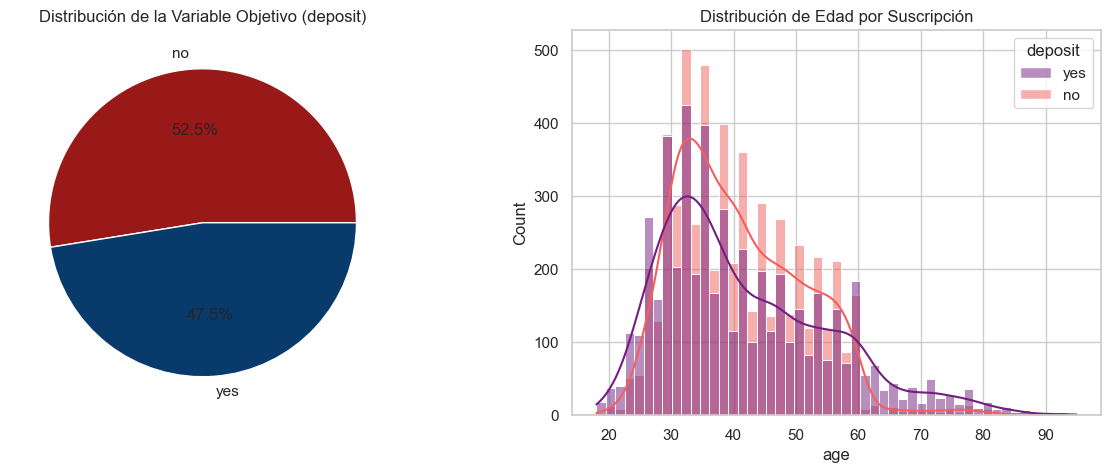

Distribución de clases:
deposit
no     52.55
yes    47.45
Name: proportion, dtype: float64

→ Dataset razonablemente BALANCEADO (diferencia de solo 5.1%).


In [29]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

dataframe['deposit'].value_counts(normalize=True).plot.pie(
    autopct='%1.1f%%', ax=ax[0], colors=["#991919", "#083a6b"]
)
ax[0].set_title('Distribución de la Variable Objetivo (deposit)')

sns.histplot(data=dataframe, x='age', hue='deposit', kde=True, ax=ax[1], palette='magma')
ax[1].set_title('Distribución de Edad por Suscripción')
plt.show()

porcentajes = dataframe['deposit'].value_counts(normalize=True) * 100
print(f"Distribución de clases:\n{porcentajes.round(2)}")
diferencia = abs(porcentajes.iloc[0] - porcentajes.iloc[1])
if diferencia > 20:
    print(f"\n→ Dataset DESBALANCEADO (diferencia del {diferencia:.1f}%).")
else:
    print(f"\n→ Dataset razonablemente BALANCEADO (diferencia de solo {diferencia:.1f}%).")

### 2.3 Análisis y preproceso de la variable `pdays`

Según el diccionario, `pdays` vale **-1** cuando el cliente no fue contactado en campañas anteriores. Ese -1 es un valor centinela, no un número de días real, por lo que necesita tratamiento especial.

**Decisión de preproceso (dentro del pipeline):**
1. Se crea una variable binaria `pdays_no_previo` (1 si pdays == -1, es decir, sin contacto previo; 0 si sí lo hubo).
2. Se reemplaza el -1 por 0 en `pdays` para que el valor numérico sea coherente con "0 días desde el contacto".

Este preproceso se implementa **dentro del `ColumnTransformer`** mediante un `FunctionTransformer`, garantizando que se aplique automáticamente tanto en train como en el conjunto de competición, sin necesidad de hacerlo a mano fuera del pipeline.

In [30]:
print("── DISTRIBUCIÓN ORIGINAL DE 'pdays' (Top 5) ──")
print(dataframe['pdays'].value_counts().head())
print(f"\nValores -1 (sin contacto previo): {(dataframe['pdays'] == -1).sum()} ({(dataframe['pdays'] == -1).mean()*100:.1f}%)")
print("\nEl preproceso se realizará DENTRO del pipeline (ver sección 3).")

── DISTRIBUCIÓN ORIGINAL DE 'pdays' (Top 5) ──
pdays
-1      8203
 92      105
 182      88
 91       82
 181      79
Name: count, dtype: int64

Valores -1 (sin contacto previo): 8203 (74.6%)

El preproceso se realizará DENTRO del pipeline (ver sección 3).


---
## 3. Estrategia de Evaluación

| Nivel | Método | Detalle |
|---|---|---|
| **Outer** (estimación rendimiento futuro) | Holdout | Train 2/3 – Test 1/3, estratificado |
| **Inner** (HPO y comparación de modelos) | Stratified K-Fold | 5 folds, shuffle=True |
| **Métrica principal** | ROC-AUC | Robusta ante desbalanceo y no requiere umbral fijo |




In [31]:
X = dataframe.drop('deposit', axis=1)
y = dataframe['deposit'].map({'yes': 1, 'no': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=RANDOM_STATE, stratify=y
)

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring_metric = 'roc_auc'

print(f"Estrategia de evaluación definida.")
print(f"   Métrica principal: ROC-AUC")
print(f"   Train: {X_train.shape[0]} instancias | Test: {X_test.shape[0]} instancias")

Estrategia de evaluación definida.
   Métrica principal: ROC-AUC
   Train: 7333 instancias | Test: 3667 instancias


### Definición del preprocesador (pipeline)

Se distinguen cuatro grupos de variables:
- **Numéricas estándar**: imputación por mediana.
- **Categóricas con unknowns** (`job`, `education`): imputación por moda + OHE.
- **Categóricas sin nulos**: directamente OHE.
- **`pdays`**: transformación personalizada (genera `pdays_no_previo` y reemplaza -1 por 0).

In [32]:
num_cols          = ['age', 'balance', 'day', 'duration', 'campaign', 'previous']
cat_cols_con_nulos = ['job', 'education']
cat_cols          = ['marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
pdays_col         = ['pdays']

#transformación personalizada de pdays
def transform_pdays(X):
    """Convierte pdays en dos columnas:
    - pdays_no_previo : 1 si no hubo contacto previo (pdays == -1), 0 si sí.
    - pdays_dias      : días desde el contacto previo (0 si no hubo).
    """
    vals = np.array(X).flatten()
    no_previo = (vals == -1).astype(int)
    dias = np.where(vals == -1, 0, vals)
    return np.column_stack((no_previo, dias))

def get_pdays_names(transformer, feature_names):
    return ['pdays_no_previo', 'pdays_dias']

pdays_transformer = FunctionTransformer(
    transform_pdays, validate=False, feature_names_out=get_pdays_names
)

#sub-pipelines
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

cat_nulos_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

cat_pipe = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

#columnTransformer final
preprocessor = ColumnTransformer(transformers=[
    ('num',          num_pipe,          num_cols),
    ('cat_nulos',    cat_nulos_pipe,    cat_cols_con_nulos),
    ('cat_normales', cat_pipe,          cat_cols),
    ('pdays_custom', pdays_transformer, pdays_col)
], remainder='drop')

print("Preprocesador definido correctamente.")

Preprocesador definido correctamente.


---
## 4. Métodos Básicos: KNN y Árboles de Decisión

### 4.0 Modelo Dummy (Baseline)

Antes de evaluar ningún modelo real, establecemos el rendimiento mínimo que hay que superar. Usamos un `DummyClassifier` con estrategia `most_frequent` (siempre predice la clase mayoritaria).

In [33]:
dummy_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('dummy', DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
])

cv_dummy = cross_val_score(dummy_pipe, X_train, y_train, cv=cv_inner, scoring=scoring_metric, n_jobs=-1)
print(f"Dummy Classifier (most_frequent) — ROC-AUC inner: {cv_dummy.mean():.4f}")
print("Cualquier modelo real debe superar esta cifra para ser útil.")

Dummy Classifier (most_frequent) — ROC-AUC inner: 0.5000
Cualquier modelo real debe superar esta cifra para ser útil.


### 4.1 KNN — Elección del método de escalado

KNN es sensible a la escala. Evaluamos los tres escaladores (StandardScaler, MinMaxScaler, RobustScaler) mediante GridSearchCV junto con el número de vecinos óptimo.

In [34]:
#evaluación por defecto (StandardScaler, k=5)
knn_default_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

inicio = time.time()
knn_default_pipe.fit(X_train, y_train)
tiempo_knn_def = time.time() - inicio

cv_knn_def = cross_val_score(knn_default_pipe, X_train, y_train, cv=cv_inner, scoring=scoring_metric, n_jobs=-1)
print(f"KNN Default (Standard, k=5) — Tiempo: {tiempo_knn_def:.4f}s | ROC-AUC: {cv_knn_def.mean():.4f}")

KNN Default (Standard, k=5) — Tiempo: 0.1265s | ROC-AUC: 0.8189


In [35]:
#HPO KNN: comparación de escaladores y número de vecinos
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35]
}

grid_knn = GridSearchCV(knn_pipeline, param_grid_knn, scoring=scoring_metric, cv=cv_inner, n_jobs=-1)

print("Entrenando GridSearch KNN (escaladores × vecinos)...")
inicio = time.time()
grid_knn.fit(X_train, y_train)
tiempo_knn_hpo = time.time() - inicio

print(f"Completado en {tiempo_knn_hpo:.2f}s")
print(f"Mejor combinación : {grid_knn.best_params_}")
print(f"Mejor ROC-AUC     : {grid_knn.best_score_:.4f}")

Entrenando GridSearch KNN (escaladores × vecinos)...
Completado en 7.54s
Mejor combinación : {'knn__n_neighbors': 21, 'scaler': RobustScaler()}
Mejor ROC-AUC     : 0.8786


In [36]:
#tabla comparativa de escaladores
knn_res = pd.DataFrame(grid_knn.cv_results_)
knn_res['escalador'] = knn_res['param_scaler'].apply(lambda x: type(x).__name__)
tabla_escaladores = (
    knn_res.groupby('escalador')['mean_test_score']
    .max()
    .reset_index()
    .rename(columns={'mean_test_score': 'Mejor ROC-AUC (inner)'})
    .sort_values('Mejor ROC-AUC (inner)', ascending=False)
)
print("── Comparación de escaladores (mejor k para cada uno) ──")
display(tabla_escaladores)
mejor_escalador = grid_knn.best_params_['scaler'].__class__.__name__
print(f"\n→ Escalador seleccionado: {mejor_escalador}")

── Comparación de escaladores (mejor k para cada uno) ──


,escalador,Mejor ROC-AUC (inner)
1,RobustScaler,0.878590
2,StandardScaler,0.844801
0,MinMaxScaler,0.819870



→ Escalador seleccionado: RobustScaler


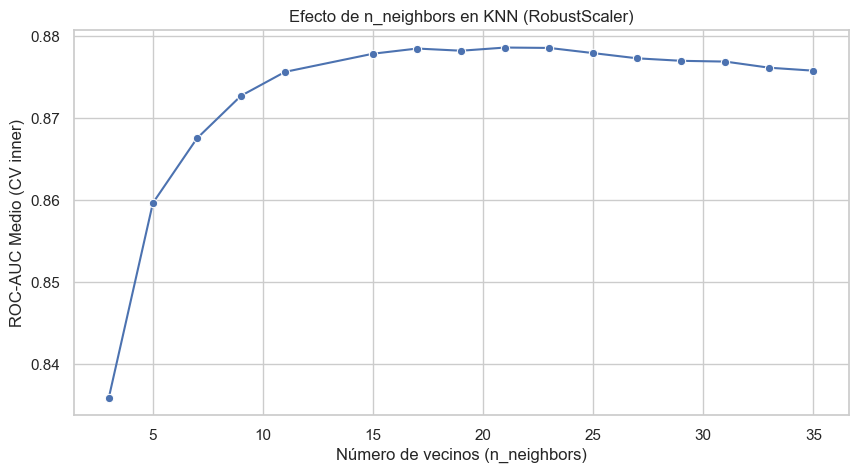

In [37]:
#gráfico: efecto de n_neighbors con el mejor escalador
knn_mejor_esc = knn_res[knn_res['escalador'] == mejor_escalador].copy()

plt.figure(figsize=(10, 5))
sns.lineplot(data=knn_mejor_esc, x='param_knn__n_neighbors', y='mean_test_score', marker='o')
plt.title(f"Efecto de n_neighbors en KNN ({mejor_escalador})")
plt.xlabel("Número de vecinos (n_neighbors)")
plt.ylabel("ROC-AUC Medio (CV inner)")
plt.grid(True)
plt.show()

### 4.2 Árboles de Decisión

In [38]:
#evaluación por defecto
tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('tree', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

inicio = time.time()
tree_pipeline.fit(X_train, y_train)
tiempo_tree_def = time.time() - inicio

cv_tree_def = cross_val_score(tree_pipeline, X_train, y_train, cv=cv_inner, scoring=scoring_metric, n_jobs=-1)
print(f"Árbol Default — Tiempo: {tiempo_tree_def:.4f}s | ROC-AUC: {cv_tree_def.mean():.4f}")

Árbol Default — Tiempo: 0.2383s | ROC-AUC: 0.7836


In [39]:
#HPO Árbol
param_grid_tree = {
    'tree__max_depth': [3, 5, 7, 10, None],
    'tree__min_samples_split': [2, 5, 10, 20],
    'tree__criterion': ['gini', 'entropy']
}

grid_tree = GridSearchCV(tree_pipeline, param_grid_tree, scoring=scoring_metric, cv=cv_inner, n_jobs=-1)

inicio = time.time()
grid_tree.fit(X_train, y_train)
tiempo_tree_hpo = time.time() - inicio

print(f"GridSearch Árbol completado en {tiempo_tree_hpo:.2f}s")
print(f"Mejor combinación : {grid_tree.best_params_}")
print(f"Mejor ROC-AUC     : {grid_tree.best_score_:.4f}")

GridSearch Árbol completado en 2.71s
Mejor combinación : {'tree__criterion': 'entropy', 'tree__max_depth': 10, 'tree__min_samples_split': 20}
Mejor ROC-AUC     : 0.8834


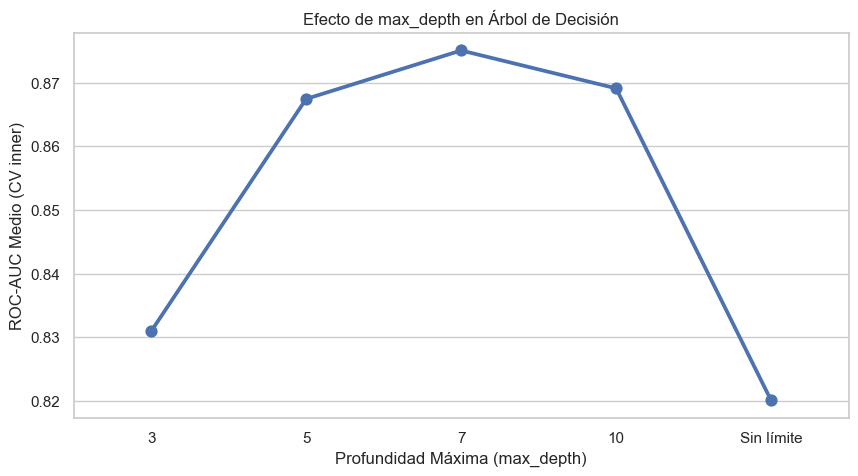

In [40]:
#gráfico: efecto de max_depth
tree_res = pd.DataFrame(grid_tree.cv_results_)
tree_res['param_tree__max_depth'] = tree_res['param_tree__max_depth'].fillna('Sin límite').astype(str)
tree_plot = tree_res.groupby('param_tree__max_depth')['mean_test_score'].max().reset_index()

plt.figure(figsize=(10, 5))
sns.pointplot(data=tree_res, x='param_tree__max_depth', y='mean_test_score', errorbar=None)
plt.title("Efecto de max_depth en Árbol de Decisión")
plt.xlabel("Profundidad Máxima (max_depth)")
plt.ylabel("ROC-AUC Medio (CV inner)")
plt.grid(True, axis='y')
plt.show()

#### Árbol poco profundo — Interpretabilidad

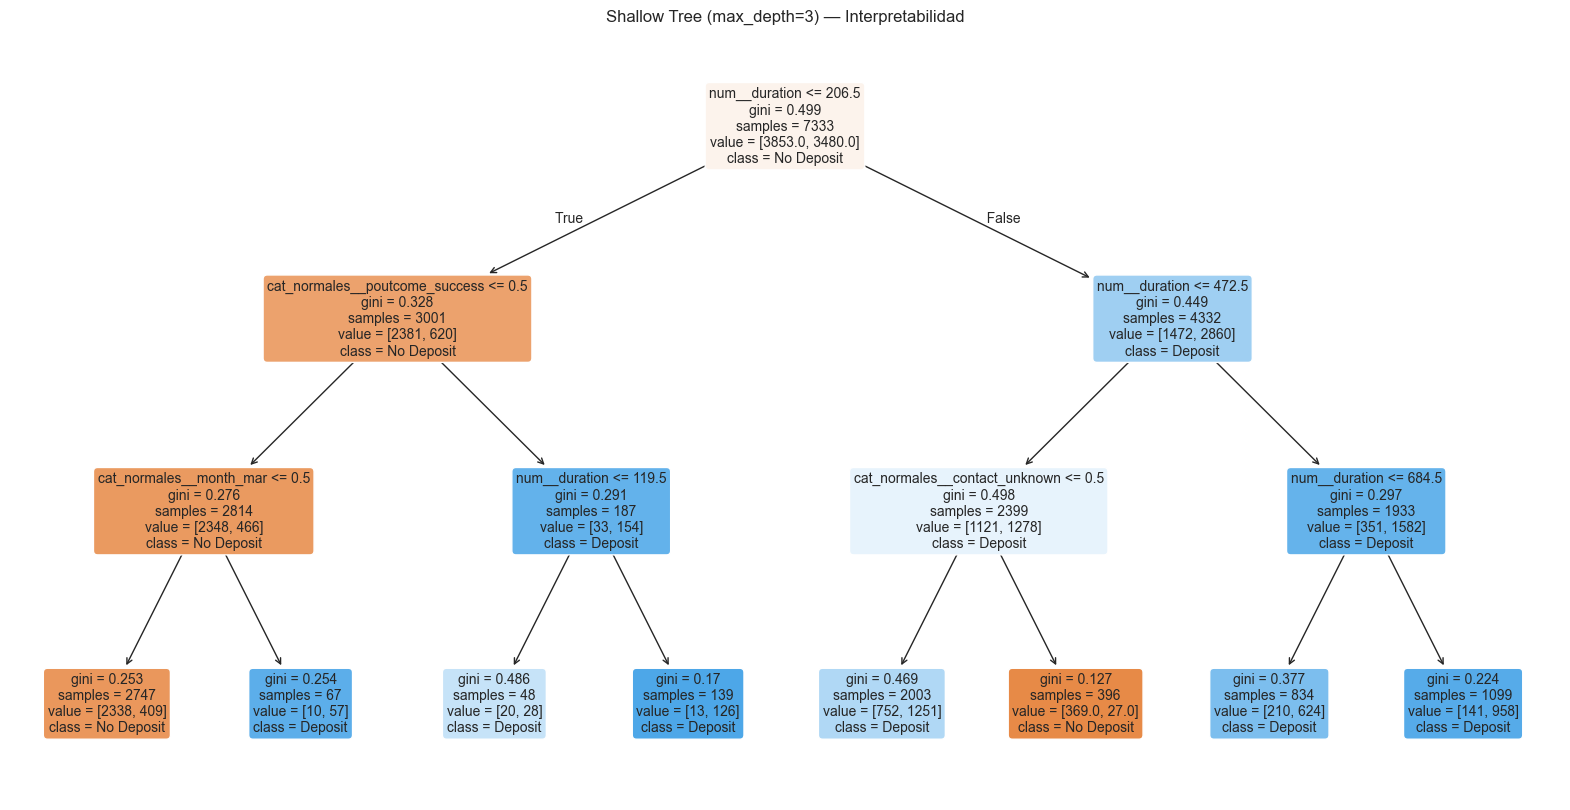

In [41]:
shallow_tree_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('tree', DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE))
])
shallow_tree_pipe.fit(X_train, y_train)

modelo_arbol = shallow_tree_pipe.named_steps['tree']
nombres_features = shallow_tree_pipe.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    modelo_arbol, feature_names=nombres_features,
    class_names=['No Deposit', 'Deposit'], filled=True, rounded=True, fontsize=10
)
plt.title("Shallow Tree (max_depth=3) — Interpretabilidad")
plt.show()

#### Conclusiones de métodos básicos (KNN vs Árboles)

* **Árbol de Decisión**: Se observa sobreajuste cuando `max_depth` es muy alto o ilimitado. El GridSearch selecciona automáticamente la profundidad óptima que balancea sesgo/varianza.
* **KNN**: Muy dependiente del escalador. RobustScaler obtiene mejores resultados al manejar los outliers de variables como `balance`. El número óptimo de vecinos tiende a ser alto (≥15), generando fronteras de decisión más suaves.
* Ambos superan claramente el modelo Dummy (ROC-AUC ≈ 0.5).
* La HPO mejora los resultados respecto a los valores por defecto con un coste computacional aceptable.

---
## 5. Métodos Avanzados: Modelos Lineales y SVMs

Evaluamos tres métodos: Regresión Logística (L2), Regresión Logística con regularización L1 y SVM.

In [42]:
#definición de pipelines (usando el escalador ganador de KNN)
logreg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', RobustScaler()),
    ('logreg', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

logreg_l1_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', RobustScaler()),
    ('logreg_l1', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, random_state=RANDOM_STATE))
])

svm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', RobustScaler()),
    ('svm', SVC(random_state=RANDOM_STATE, probability=True))
])

#evaluación por defecto
def evaluar_default(pipeline, nombre):
    inicio = time.time()
    pipeline.fit(X_train, y_train)
    tiempo_fit = time.time() - inicio
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv_inner, scoring=scoring_metric, n_jobs=-1)
    print(f"{nombre:<40} | Tiempo: {tiempo_fit:.3f}s | ROC-AUC: {cv_scores.mean():.4f}")
    return cv_scores.mean()

print("── Evaluación con hiperparámetros por defecto ──")
evaluar_default(logreg_pipe,    "LogReg (L2, default)")
evaluar_default(logreg_l1_pipe, "LogReg L1 (default)")
evaluar_default(svm_pipe,       "SVM (default)")

── Evaluación con hiperparámetros por defecto ──
LogReg (L2, default)                     | Tiempo: 0.299s | ROC-AUC: 0.9041
LogReg L1 (default)                      | Tiempo: 0.127s | ROC-AUC: 0.9046
SVM (default)                            | Tiempo: 16.376s | ROC-AUC: 0.8921


np.float64(0.892148025655338)

In [43]:
#HPO: Regresión Logística L2
param_grid_logreg = {'logreg__C': [0.01, 0.1, 1, 10, 100]}

grid_logreg = GridSearchCV(logreg_pipe, param_grid_logreg, scoring=scoring_metric, cv=cv_inner, n_jobs=-1)
inicio = time.time()
grid_logreg.fit(X_train, y_train)
tiempo_logreg_hpo = time.time() - inicio

print(f"LogReg L2 — Mejor C={grid_logreg.best_params_['logreg__C']} | ROC-AUC: {grid_logreg.best_score_:.4f} | Tiempo: {tiempo_logreg_hpo:.2f}s")

LogReg L2 — Mejor C=100 | ROC-AUC: 0.9047 | Tiempo: 1.85s


In [44]:
#HPO: Regresión Logística L1
param_grid_logreg_l1 = {'logreg_l1__C': [0.01, 0.1, 1, 10, 100]}

grid_logreg_l1 = GridSearchCV(logreg_l1_pipe, param_grid_logreg_l1, scoring=scoring_metric, cv=cv_inner, n_jobs=-1)
inicio = time.time()
grid_logreg_l1.fit(X_train, y_train)
tiempo_l1_hpo = time.time() - inicio

print(f"LogReg L1 — Mejor C={grid_logreg_l1.best_params_['logreg_l1__C']} | ROC-AUC: {grid_logreg_l1.best_score_:.4f} | Tiempo: {tiempo_l1_hpo:.2f}s")

LogReg L1 — Mejor C=100 | ROC-AUC: 0.9047 | Tiempo: 1.01s


In [45]:
#HPO: SVM (grid pequeña por coste computacional)
param_grid_svm = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(svm_pipe, param_grid_svm, scoring=scoring_metric, cv=cv_inner, n_jobs=-1)
inicio = time.time()
grid_svm.fit(X_train, y_train)
tiempo_svm_hpo = time.time() - inicio

print(f"SVM — Mejor params={grid_svm.best_params_} | ROC-AUC: {grid_svm.best_score_:.4f} | Tiempo: {tiempo_svm_hpo:.2f}s")

SVM — Mejor params={'svm__C': 10, 'svm__kernel': 'linear'} | ROC-AUC: 0.9046 | Tiempo: 535.77s


Variables con coeficiente = 0 (eliminadas por L1): 0
Variables activas: 54


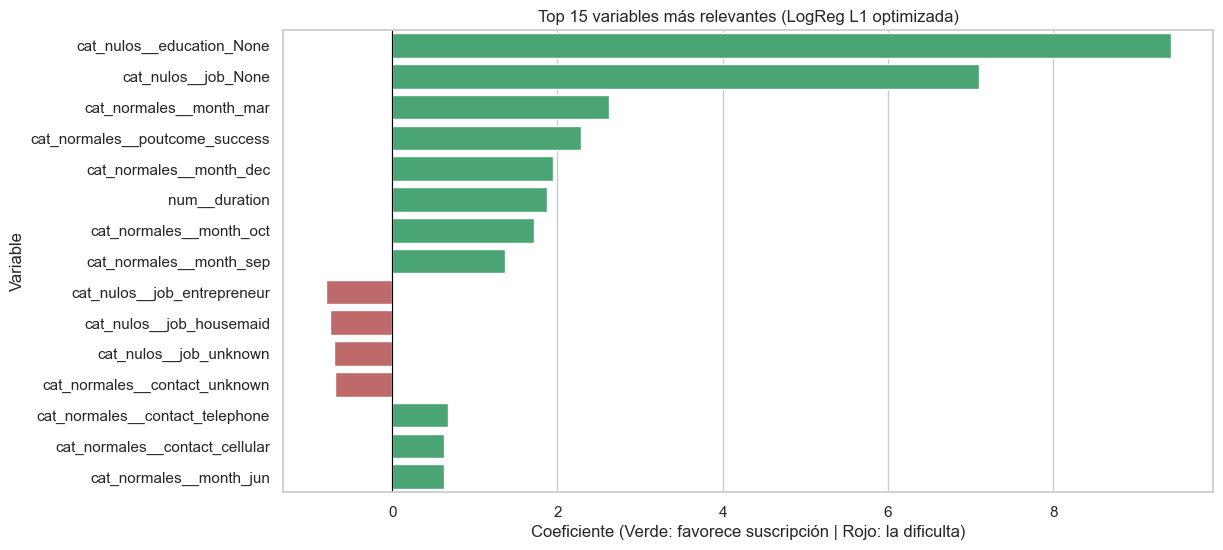

In [46]:
#importancia de variables desde Regresión Logística L1
#L1 hace selección de variables al forzar coeficientes a 0
mejor_l1_pipe = grid_logreg_l1.best_estimator_
modelo_l1 = mejor_l1_pipe.named_steps['logreg_l1']
nombres_vars = mejor_l1_pipe.named_steps['preprocessor'].get_feature_names_out()
coeficientes = modelo_l1.coef_[0]

importancia_df = pd.DataFrame({
    'Variable': nombres_vars,
    'Coeficiente': coeficientes,
    'Importancia_Absoluta': np.abs(coeficientes)
}).sort_values('Importancia_Absoluta', ascending=False)

print(f"Variables con coeficiente = 0 (eliminadas por L1): {(coeficientes == 0).sum()}")
print(f"Variables activas: {(coeficientes != 0).sum()}")

top15 = importancia_df.head(15)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top15, x='Coeficiente', y='Variable',
    hue=top15['Coeficiente'] > 0,
    palette={True: 'mediumseagreen', False: 'indianred'}, legend=False
)
plt.title("Top 15 variables más relevantes (LogReg L1 optimizada)")
plt.xlabel("Coeficiente (Verde: favorece suscripción | Rojo: la dificulta)")
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(True, axis='x')
plt.show()

---
## 6. Resultados y Modelo Final

### 6.1 Tabla comparativa — Evaluación Inner (todos los modelos)

In [47]:
#recalculamos el baseline KNN y árbol con defaults para la tabla
cv_knn_def_score  = cross_val_score(knn_default_pipe,  X_train, y_train, cv=cv_inner, scoring=scoring_metric, n_jobs=-1).mean()
cv_tree_def_score = cross_val_score(tree_pipeline,     X_train, y_train, cv=cv_inner, scoring=scoring_metric, n_jobs=-1).mean()

resumen_modelos = pd.DataFrame([
    {'Modelo': 'Dummy (baseline)',     'Config': 'most_frequent',            'ROC-AUC Inner': cv_dummy.mean(),          'HPO': 'No'},
    {'Modelo': 'KNN',                  'Config': 'Default (k=5, Standard)',   'ROC-AUC Inner': cv_knn_def_score,         'HPO': 'No'},
    {'Modelo': 'KNN (HPO)',            'Config': str(grid_knn.best_params_),  'ROC-AUC Inner': grid_knn.best_score_,     'HPO': 'Sí'},
    {'Modelo': 'Árbol Decisión',       'Config': 'Default',                  'ROC-AUC Inner': cv_tree_def_score,        'HPO': 'No'},
    {'Modelo': 'Árbol Decisión (HPO)', 'Config': str(grid_tree.best_params_), 'ROC-AUC Inner': grid_tree.best_score_,   'HPO': 'Sí'},
    {'Modelo': 'LogReg L2 (HPO)',      'Config': str(grid_logreg.best_params_),'ROC-AUC Inner': grid_logreg.best_score_, 'HPO': 'Sí'},
    {'Modelo': 'LogReg L1 (HPO)',      'Config': str(grid_logreg_l1.best_params_),'ROC-AUC Inner': grid_logreg_l1.best_score_,'HPO': 'Sí'},
    {'Modelo': 'SVM (HPO)',            'Config': str(grid_svm.best_params_),  'ROC-AUC Inner': grid_svm.best_score_,    'HPO': 'Sí'},
])

resumen_modelos = resumen_modelos.sort_values('ROC-AUC Inner', ascending=False)
resumen_modelos['ROC-AUC Inner'] = resumen_modelos['ROC-AUC Inner'].round(4)
display(resumen_modelos)

mejor_nombre = resumen_modelos.iloc[0]['Modelo']
print(f"\nModelo seleccionado: {mejor_nombre}")

,Modelo,Config,ROC-AUC Inner,HPO
6,LogReg L1 (HPO),{'logreg_l1__C': 100},0.9047,Sí
5,LogReg L2 (HPO),{'logreg__C': 100},0.9047,Sí
7,SVM (HPO),"{'svm__C': 10, 'svm__kernel': 'linear'}",0.9046,Sí
4,Árbol Decisión (HPO),"{'tree__criterion': 'entropy', 'tree__max_dept...",0.8834,Sí
2,KNN (HPO),"{'knn__n_neighbors': 21, 'scaler': RobustScale...",0.8786,Sí
1,KNN,"Default (k=5, Standard)",0.8189,No
3,Árbol Decisión,Default,0.7836,No
0,Dummy (baseline),most_frequent,0.5000,No



Modelo seleccionado: LogReg L1 (HPO)


### 6.2 Evaluación Outer — Estimación del rendimiento futuro



ESTIMACIÓN DEL RENDIMIENTO FUTURO (OUTER)
              precision    recall  f1-score   support

  No deposit       0.82      0.87      0.84      1927
     Deposit       0.84      0.79      0.82      1740

    accuracy                           0.83      3667
   macro avg       0.83      0.83      0.83      3667
weighted avg       0.83      0.83      0.83      3667

ROC-AUC en Test: 0.9169


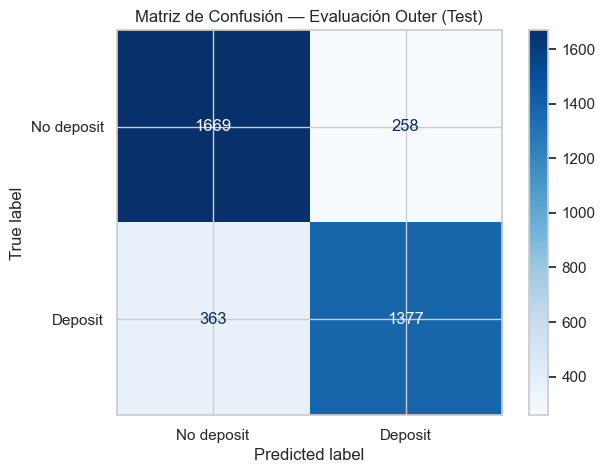

In [48]:
#seleccionamos el grid del mejor modelo según la tabla anterior

mejor_grid = grid_logreg_l1  
mejor_pipeline = mejor_grid.best_estimator_

y_pred_test  = mejor_pipeline.predict(X_test)
y_probs_test = mejor_pipeline.predict_proba(X_test)[:, 1]

#impresion de resultados 
print("ESTIMACIÓN DEL RENDIMIENTO FUTURO (OUTER)")
print(classification_report(y_test, y_pred_test, target_names=['No deposit', 'Deposit']))
print(f"ROC-AUC en Test: {roc_auc_score(y_test, y_probs_test):.4f}")

#matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(cm, display_labels=['No deposit', 'Deposit']).plot(cmap='Blues', ax=ax)
ax.set_title("Matriz de Confusión — Evaluación Outer (Test)")
plt.show()

### 6.3 Entrenamiento del modelo final y guardado

In [49]:
#reentrenamos con TODOS los datos (train + test)
mejor_pipeline.fit(X, y)

#guardamos con joblib
joblib.dump(mejor_pipeline, 'modelo_final.joblib')
print("Modelo final guardado como 'modelo_final.joblib'")

Modelo final guardado como 'modelo_final.joblib'


## 7. Tarea de elección abierta: Curva ROC comparativa

Se ha añadido una visualización de la curva ROC para todos los modelos optimizados
evaluados sobre el conjunto de test. La curva ROC permite comparar visualmente el
trade-off entre tasa de verdaderos positivos y falsos positivos para distintos
umbrales de decisión, complementando la métrica ROC-AUC usada durante la práctica.
Esta visualización es especialmente útil en el contexto bancario, donde el coste
de un falso negativo (no contactar a un cliente que sí hubiera suscrito) puede ser
muy diferente al de un falso positivo (contactar a alguien que no va a suscribir).

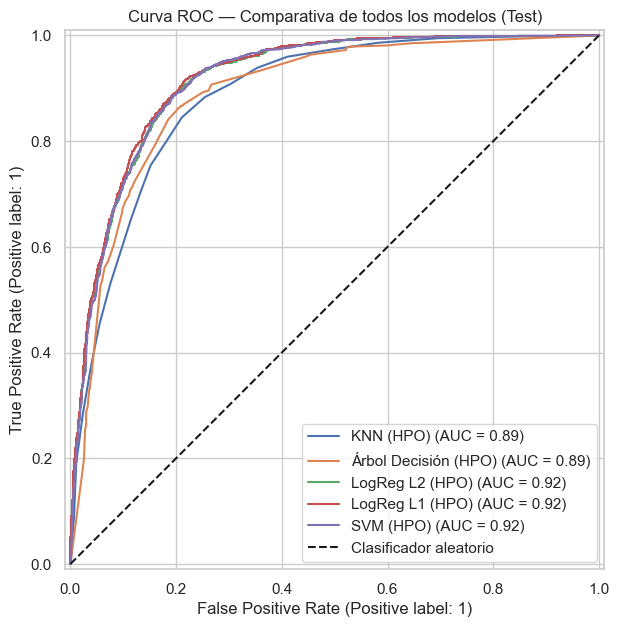

In [50]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(10, 7))

#pintamos la curva ROC de cada modelo optimizado
for grid, nombre in [
    (grid_knn,        'KNN (HPO)'),
    (grid_tree,       'Árbol Decisión (HPO)'),
    (grid_logreg,     'LogReg L2 (HPO)'),
    (grid_logreg_l1,  'LogReg L1 (HPO)'),
    (grid_svm,        'SVM (HPO)'),
]:
    RocCurveDisplay.from_estimator(
        grid.best_estimator_, X_test, y_test,
        name=nombre, ax=ax
    )

ax.set_title("Curva ROC — Comparativa de todos los modelos (Test)")
ax.plot([0,1],[0,1], 'k--', label='Clasificador aleatorio')
ax.legend(loc='lower right')
plt.show()

## 8. USO DE IA GENERATIVA
Para esta práctica hemos utilizado la IA GENERATIVA, fundamentalmente para la correción de errores. Además, para la salida de resultados con una interfaz visible, tanto como prints como gráficos.
Como el uso de esta herramienta ha sido recurrente en los outputs, no especificamos celdas por limpieza visual del notebook sobretodo.
